In [1]:
import polars as pl

path = './Files/Sample_Superstore.csv'
df = pl.read_csv(path)

In [2]:
df.group_by('Category').agg(pl.col('Profit').count())

Category,Profit
str,u32
"""Technology""",1847
"""Furniture""",2121
"""Office Supplies""",6026


In [47]:
df.group_by(pl.col('Category')).count()

C:\Users\SHOLAR\AppData\Local\Temp\ipykernel_1076\2245644799.py:1: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  df.group_by(pl.col('Category')).count()


Category,count
str,u32
"""Technology""",1847
"""Office Supplies""",6026
"""Furniture""",2121


In [3]:
df.group_by('Category').agg(pl.col('Profit').min())

Category,Profit
str,f64
"""Technology""",-6599.978
"""Furniture""",-1862.3124
"""Office Supplies""",-3701.8928


In [4]:
df.group_by('Category').agg(pl.col('Profit').sum())

Category,Profit
str,f64
"""Technology""",145454.9481
"""Office Supplies""",122490.8008
"""Furniture""",18451.2728


In [5]:
df.group_by('Category', 'Region').agg(pl.col('Profit').sum())

Category,Region,Profit
str,str,f64
"""Office Supplies""","""South""",19986.3928
"""Technology""","""West""",44303.6496
"""Office Supplies""","""East""",41014.5791
"""Technology""","""Central""",33697.432
"""Furniture""","""Central""",-2871.0494
…,…,…
"""Furniture""","""South""",6771.2061
"""Office Supplies""","""Central""",8879.9799
"""Furniture""","""East""",3046.1658


In [6]:
df.group_by(pl.col('Row_ID').cast(pl.Int64)).agg(pl.col('Profit').sum())

Row_ID,Profit
i64,f64
1659,10.0485
575,2.3814
8971,-25.198
6056,-3.4122
3576,4.8924
…,…
1372,4.908
6103,28.3095
6326,103.3116


In [7]:
df.group_by('Category', maintain_order=True).agg(pl.col('Profit').sum())

Category,Profit
str,f64
"""Furniture""",18451.2728
"""Office Supplies""",122490.8008
"""Technology""",145454.9481


In [8]:
df.group_by('Category').agg(pl.col('Profit').max().alias('total_profit')).filter(pl.col('total_profit')  > 1000)
#HAVING

Category,total_profit
str,f64
"""Office Supplies""",4946.37
"""Furniture""",1013.127
"""Technology""",8399.976


In [9]:
import polars.selectors as cs

obj = df.group_by('Category')
obj

In [12]:
for cat, g_df in obj:
    display(cat)
    display(g_df.head(3))
    print('\n')

('Office Supplies',)

Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
i64,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,f64,i64,f64,f64
3,"""CA-2016-138688""","""12-06-2016""",null,null,"""DV-13045""","""Darrin Van Huff""","""Corporate""",null,"""Los Angeles""","""California""",90036,"""West""","""OFF-LA-10000240""","""Office Supplies""","""Labels""","""Self-Adhesive Address Labels f…",14.62,2,0.0,6.8714
5,"""US-2015-108966""","""11-10-2015""","""18-10-2015""","""Standard Class""","""SO-20335""","""Sean O'Donnell""","""Consumer""","""United States""",null,"""Florida""",33311,"""South""","""OFF-ST-10000760""","""Office Supplies""","""Storage""","""Eldon Fold 'N Roll Cart System""",22.368,2,0.2,2.5164
7,"""CA-2014-115812""","""09-06-2014""","""14-06-2014""","""Standard Class""","""BH-11710""","""Brosina Hoffman""","""Consumer""","""United States""","""Los Angeles""","""California""",90032,"""West""","""OFF-AR-10002833""","""Office Supplies""","""Art""","""Newell 322""",7.28,4,0.0,1.9656


('Furniture',)

Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
i64,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,f64,i64,f64,f64
1,null,null,"""11-11-2016""","""Second Class""","""CG-12520""","""Claire Gute""","""Consumer""","""United States""","""Henderson""","""Kentucky""",42420,"""South""","""FUR-BO-10001798""","""Furniture""","""Bookcases""","""Bush Somerset Collection Bookc…",261.96,2,0.0,41.9136
2,"""CA-2016-152156""","""08-11-2016""","""11-11-2016""","""Second Class""","""CG-12520""","""Claire Gute""","""Consumer""","""United States""","""Henderson""","""Kentucky""",42420,"""South""","""FUR-CH-10000454""","""Furniture""","""Chairs""","""Hon Deluxe Fabric Upholstered …",731.94,3,0.0,219.582
4,null,"""11-10-2015""",null,"""Standard Class""","""SO-20335""","""Sean O'Donnell""","""Consumer""","""United States""","""Fort Lauderdale""","""Florida""",33311,"""South""","""FUR-TA-10000577""","""Furniture""","""Tables""","""Bretford CR4500 Series Slim Re…",957.5775,5,0.45,-383.031


('Technology',)

Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
i64,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,f64,i64,f64,f64
8,"""CA-2014-115812""","""09-06-2014""","""14-06-2014""","""Standard Class""","""BH-11710""","""Brosina Hoffman""","""Consumer""",null,"""Los Angeles""","""California""",90032,"""West""","""TEC-PH-10002275""","""Technology""","""Phones""","""Mitel 5320 IP Phone VoIP phone""",907.152,6,0.2,90.7152
12,"""CA-2014-115812""","""09-06-2014""","""14-06-2014""","""Standard Class""","""BH-11710""","""Brosina Hoffman""","""Consumer""","""United States""","""Los Angeles""","""California""",90032,"""West""","""TEC-PH-10002033""","""Technology""","""Phones""","""Konftel 250 Conference phone -…",911.424,4,0.2,68.3568
20,"""CA-2014-143336""","""27-08-2014""","""01-09-2014""","""Second Class""","""ZD-21925""","""Zuschuss Donatelli""","""Consumer""","""United States""","""San Francisco""","""California""",94109,"""West""","""TEC-PH-10001949""","""Technology""","""Phones""","""Cisco SPA 501G IP Phone""",213.48,3,0.2,16.011


In [13]:
obj.head(2)

Category,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
str,i64,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,f64,i64,f64,f64
"""Technology""",8,"""CA-2014-115812""","""09-06-2014""","""14-06-2014""","""Standard Class""","""BH-11710""","""Brosina Hoffman""","""Consumer""",null,"""Los Angeles""","""California""",90032,"""West""","""TEC-PH-10002275""","""Phones""","""Mitel 5320 IP Phone VoIP phone""",907.152,6,0.2,90.7152
"""Technology""",12,"""CA-2014-115812""","""09-06-2014""","""14-06-2014""","""Standard Class""","""BH-11710""","""Brosina Hoffman""","""Consumer""","""United States""","""Los Angeles""","""California""",90032,"""West""","""TEC-PH-10002033""","""Phones""","""Konftel 250 Conference phone -…",911.424,4,0.2,68.3568
"""Office Supplies""",3,"""CA-2016-138688""","""12-06-2016""",null,null,"""DV-13045""","""Darrin Van Huff""","""Corporate""",null,"""Los Angeles""","""California""",90036,"""West""","""OFF-LA-10000240""","""Labels""","""Self-Adhesive Address Labels f…",14.62,2,0.0,6.8714
"""Office Supplies""",5,"""US-2015-108966""","""11-10-2015""","""18-10-2015""","""Standard Class""","""SO-20335""","""Sean O'Donnell""","""Consumer""","""United States""",null,"""Florida""",33311,"""South""","""OFF-ST-10000760""","""Storage""","""Eldon Fold 'N Roll Cart System""",22.368,2,0.2,2.5164
"""Furniture""",1,null,null,"""11-11-2016""","""Second Class""","""CG-12520""","""Claire Gute""","""Consumer""","""United States""","""Henderson""","""Kentucky""",42420,"""South""","""FUR-BO-10001798""","""Bookcases""","""Bush Somerset Collection Bookc…",261.96,2,0.0,41.9136
"""Furniture""",2,"""CA-2016-152156""","""08-11-2016""","""11-11-2016""","""Second Class""","""CG-12520""","""Claire Gute""","""Consumer""","""United States""","""Henderson""","""Kentucky""",42420,"""South""","""FUR-CH-10000454""","""Chairs""","""Hon Deluxe Fabric Upholstered …",731.94,3,0.0,219.582


In [14]:
obj.len()

Category,len
str,u32
"""Office Supplies""",6026
"""Furniture""",2121
"""Technology""",1847


In [15]:
obj.max()

Category,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
str,i64,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,f64,i64,f64,f64
"""Office Supplies""",9994,"""US-2017-169551""","""31-12-2016""","""31-12-2017""","""Standard Class""","""ZD-21925""","""Zuschuss Donatelli""","""Home Office""","""United States""","""Yuma""","""Wisconsin""",99301,"""West""","""OFF-SU-10004884""","""Supplies""","""Zipper Ring Binder Pockets""",9892.74,14,0.8,4946.37
"""Furniture""",9991,"""US-2017-169551""","""31-12-2015""","""31-12-2017""","""Standard Class""","""ZD-21925""","""Zuschuss Donatelli""","""Home Office""","""United States""","""York""","""Wyoming""",99301,"""West""","""FUR-TA-10004915""","""Tables""","""Westinghouse Mesh Shade Clip-O…",4416.174,14,0.7,1013.127
"""Technology""",9992,"""US-2017-169551""","""31-12-2016""","""31-12-2016""","""Standard Class""","""ZD-21925""","""Zuschuss Donatelli""","""Home Office""","""United States""","""Yuma""","""Wisconsin""",99207,"""West""","""TEC-PH-10004977""","""Phones""","""netTALK DUO VoIP Telephone Ser…",22638.48,14,0.7,8399.976


In [17]:
obj.agg(
    pl.col(pl.Float64).min().name.suffix('_min'),
    pl.col(pl.Float64).max().name.suffix('_max')
)

Category,Sales_min,Discount_min,Profit_min,Sales_max,Discount_max,Profit_max
str,f64,f64,f64,f64,f64,f64
"""Office Supplies""",0.444,0.0,-3701.8928,9892.74,0.8,4946.37
"""Furniture""",1.892,0.0,-1862.3124,4416.174,0.7,1013.127
"""Technology""",0.99,0.0,-6599.978,22638.48,0.7,8399.976


#Case

In [19]:
reg = df.group_by('Region').agg(
    pl.sum('Profit').alias('total_profit')
    # pl.sum('Profit').alias('total_profit') can be multiple
).with_columns(
    pl.when(pl.col('total_profit') > 100000)
    .then(pl.lit('Best'))
    .when(pl.col('total_profit') > 75000)
    .then(pl.lit('Better'))
    .when(pl.col('total_profit') > 45000)
    .then(pl.lit('Good'))
    .otherwise(pl.lit('Not Good'))
    .alias('Profit_Cat')
)
reg

Region,total_profit,Profit_Cat
str,f64,str
"""West""",108418.4489,"""Best"""
"""East""",91522.78,"""Better"""
"""South""",46749.4303,"""Good"""
"""Central""",39706.3625,"""Not Good"""


In [20]:
#Quantiles and Histograms
df.quantile(0.9)

Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
f64,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,str,str,f64,f64,f64,f64
8995.0,null,null,null,null,null,null,null,null,null,null,94122.0,null,null,null,null,null,572.76,7.0,0.4,89.307


In [22]:
q_list = [0.5, 0.9, 0.1]
df.select(
    [pl.col('Profit').quantile(q).alias(f'Profit_quantile_{q}') for q in q_list]
) #quantile cn have interpolation args

Profit_quantile_0.5,Profit_quantile_0.9,Profit_quantile_0.1
f64,f64,f64
8.671,89.307,-15.4764


In [23]:
df['Profit'].hist()
# Break point right hand value of bin, Category = shows range of each bin
#Count showing number of values in each bin

breakpoint,category,count
f64,cat,u32
-5099.9826,"""[-6599.978, -5099.9826]""",1
-3599.9872,"""(-5099.9826, -3599.9872]""",2
-2099.9918,"""(-3599.9872, -2099.9918]""",4
-599.9964,"""(-2099.9918, -599.9964]""",34
899.999,"""(-599.9964, 899.999]""",9907
2399.9944,"""(899.999, 2399.9944]""",35
3899.9898,"""(2399.9944, 3899.9898]""",5
5399.9852,"""(3899.9898, 5399.9852]""",4
6899.9806,"""(5399.9852, 6899.9806]""",1


In [24]:
df['Profit'].hist(bins=list(range(0, 100, 10)))

breakpoint,category,count
f64,cat,u32
10.0,"""[0.0, 10.0]""",3516
20.0,"""(10.0, 20.0]""",1407
30.0,"""(20.0, 30.0]""",737
40.0,"""(30.0, 40.0]""",427
50.0,"""(40.0, 50.0]""",308
60.0,"""(50.0, 60.0]""",257
70.0,"""(60.0, 70.0]""",172
80.0,"""(70.0, 80.0]""",167
90.0,"""(80.0, 90.0]""",151


<Axes: title={'center': 'Profit Distribution'}, ylabel='Frequency'>

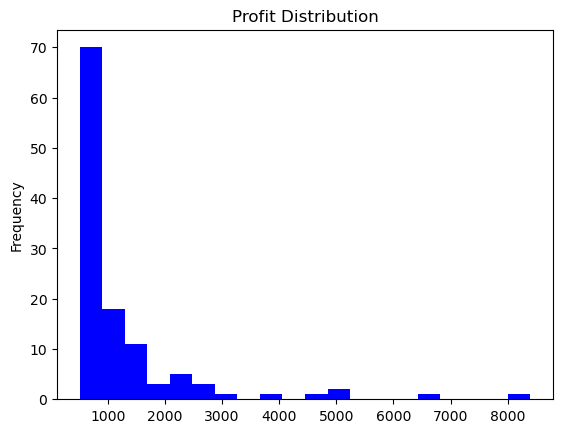

In [25]:
dfplot = df.filter(pl.col('Profit') > 500).to_pandas()
dfplot['Profit'].plot.hist(bins=20, color='blue', title='Profit Distribution')

In [26]:
#Sorting
df.sort('Customer_ID').head() #puts null values in first row us nulls_last=True t avoid this

Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
i64,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,f64,i64,f64,f64
1160,"""CA-2017-147039""","""29-06-2017""","""04-07-2017""","""Standard Class""","""AA-10315""","""Alex Avila""","""Consumer""","""United States""","""Minneapolis""","""Minnesota""",55407,"""Central""","""OFF-AP-10000576""","""Office Supplies""","""Appliances""","""Belkin 325VA UPS Surge Protect…",362.94,3,0.0,90.735
1161,"""CA-2017-147039""","""29-06-2017""","""04-07-2017""","""Standard Class""","""AA-10315""","""Alex Avila""","""Consumer""","""United States""","""Minneapolis""","""Minnesota""",55407,"""Central""","""OFF-BI-10004654""","""Office Supplies""","""Binders""","""Avery Binding System Hidden Ta…",11.54,2,0.0,5.77
1300,"""CA-2015-121391""","""04-10-2015""","""07-10-2015""","""First Class""","""AA-10315""","""Alex Avila""","""Consumer""","""United States""","""San Francisco""","""California""",94109,"""West""","""OFF-ST-10001590""","""Office Supplies""","""Storage""","""Tenex Personal Project File wi…",26.96,2,0.0,7.0096
2230,"""CA-2014-128055""","""31-03-2014""","""05-04-2014""","""Standard Class""","""AA-10315""","""Alex Avila""","""Consumer""","""United States""","""San Francisco""","""California""",94122,"""West""","""OFF-BI-10004390""","""Office Supplies""","""Binders""","""GBC DocuBind 200 Manual Bindin…",673.568,2,0.2,252.588
2231,"""CA-2014-128055""","""31-03-2014""","""05-04-2014""","""Standard Class""","""AA-10315""","""Alex Avila""","""Consumer""","""United States""","""San Francisco""","""California""",94122,"""West""","""OFF-AP-10002765""","""Office Supplies""","""Appliances""","""Fellowes Advanced Computer Ser…",52.98,2,0.0,14.8344


In [28]:
df.sort('Customer_ID', descending=True).head()

Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
i64,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,f64,i64,f64,f64
19,"""CA-2014-143336""","""27-08-2014""","""01-09-2014""","""Second Class""","""ZD-21925""","""Zuschuss Donatelli""","""Consumer""","""United States""","""San Francisco""","""California""",94109,"""West""","""OFF-AR-10003056""","""Office Supplies""","""Art""","""Newell 341""",8.56,2,0.0,2.4824
20,"""CA-2014-143336""","""27-08-2014""","""01-09-2014""","""Second Class""","""ZD-21925""","""Zuschuss Donatelli""","""Consumer""","""United States""","""San Francisco""","""California""",94109,"""West""","""TEC-PH-10001949""","""Technology""","""Phones""","""Cisco SPA 501G IP Phone""",213.48,3,0.2,16.011
21,"""CA-2014-143336""","""27-08-2014""","""01-09-2014""","""Second Class""","""ZD-21925""","""Zuschuss Donatelli""","""Consumer""","""United States""","""San Francisco""","""California""",94109,"""West""","""OFF-BI-10002215""","""Office Supplies""","""Binders""","""Wilson Jones Hanging View Bind…",22.72,4,0.2,7.384
3041,"""US-2016-147991""","""05-05-2016""","""09-05-2016""","""Standard Class""","""ZD-21925""","""Zuschuss Donatelli""","""Consumer""","""United States""","""Chattanooga""","""Tennessee""",37421,"""South""","""FUR-FU-10004270""","""Furniture""","""Furnishings""","""Eldon Image Series Desk Access…",16.72,5,0.2,3.344
3815,"""CA-2016-152471""","""08-07-2016""","""08-07-2016""","""Same Day""","""ZD-21925""","""Zuschuss Donatelli""","""Consumer""","""United States""","""Jacksonville""","""Florida""",32216,"""South""","""TEC-PH-10002824""","""Technology""","""Phones""","""Jabra SPEAK 410 Multidevice Sp…",823.96,5,0.2,51.4975


In [29]:
df.sort('Customer_ID', 'Profit').head() #or list

Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
i64,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,f64,i64,f64,f64
5199,"""CA-2016-103982""","""03-03-2016""","""08-03-2016""","""Standard Class""","""AA-10315""","""Alex Avila""","""Consumer""","""United States""","""Round Rock""","""Texas""",78664,"""Central""","""OFF-SU-10000151""","""Office Supplies""","""Supplies""","""High Speed Automatic Electric …",3930.072,3,0.2,-786.0144
5200,"""CA-2016-103982""","""03-03-2016""","""08-03-2016""","""Standard Class""","""AA-10315""","""Alex Avila""","""Consumer""","""United States""","""Round Rock""","""Texas""",78664,"""Central""","""OFF-FA-10001332""","""Office Supplies""","""Fasteners""","""Acco Banker's Clasps, 5 3/4""-L…",2.304,1,0.2,0.7776
5202,"""CA-2016-103982""","""03-03-2016""","""08-03-2016""","""Standard Class""","""AA-10315""","""Alex Avila""","""Consumer""","""United States""","""Round Rock""","""Texas""",78664,"""Central""","""TEC-AC-10002857""","""Technology""","""Accessories""","""Verbatim 25 GB 6x Blu-ray Sing…",41.72,7,0.2,5.7365
1161,"""CA-2017-147039""","""29-06-2017""","""04-07-2017""","""Standard Class""","""AA-10315""","""Alex Avila""","""Consumer""","""United States""","""Minneapolis""","""Minnesota""",55407,"""Central""","""OFF-BI-10004654""","""Office Supplies""","""Binders""","""Avery Binding System Hidden Ta…",11.54,2,0.0,5.77
7470,"""CA-2014-138100""","""15-09-2014""","""20-09-2014""","""Standard Class""","""AA-10315""","""Alex Avila""","""Consumer""","""United States""","""New York City""","""New York""",10011,"""East""","""FUR-FU-10002456""","""Furniture""","""Furnishings""","""Master Caster Door Stop, Large…",14.56,2,0.0,6.2608


In [31]:
df.select(pl.all().sort_by('Customer_ID')).head() #Sort selected columns

Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
i64,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,f64,i64,f64,f64
1160,"""CA-2017-147039""","""29-06-2017""","""04-07-2017""","""Standard Class""","""AA-10315""","""Alex Avila""","""Consumer""","""United States""","""Minneapolis""","""Minnesota""",55407,"""Central""","""OFF-AP-10000576""","""Office Supplies""","""Appliances""","""Belkin 325VA UPS Surge Protect…",362.94,3,0.0,90.735
1161,"""CA-2017-147039""","""29-06-2017""","""04-07-2017""","""Standard Class""","""AA-10315""","""Alex Avila""","""Consumer""","""United States""","""Minneapolis""","""Minnesota""",55407,"""Central""","""OFF-BI-10004654""","""Office Supplies""","""Binders""","""Avery Binding System Hidden Ta…",11.54,2,0.0,5.77
1300,"""CA-2015-121391""","""04-10-2015""","""07-10-2015""","""First Class""","""AA-10315""","""Alex Avila""","""Consumer""","""United States""","""San Francisco""","""California""",94109,"""West""","""OFF-ST-10001590""","""Office Supplies""","""Storage""","""Tenex Personal Project File wi…",26.96,2,0.0,7.0096
2230,"""CA-2014-128055""","""31-03-2014""","""05-04-2014""","""Standard Class""","""AA-10315""","""Alex Avila""","""Consumer""","""United States""","""San Francisco""","""California""",94122,"""West""","""OFF-BI-10004390""","""Office Supplies""","""Binders""","""GBC DocuBind 200 Manual Bindin…",673.568,2,0.2,252.588
2231,"""CA-2014-128055""","""31-03-2014""","""05-04-2014""","""Standard Class""","""AA-10315""","""Alex Avila""","""Consumer""","""United States""","""San Francisco""","""California""",94122,"""West""","""OFF-AP-10002765""","""Office Supplies""","""Appliances""","""Fellowes Advanced Computer Ser…",52.98,2,0.0,14.8344


In [32]:
df.group_by('Region').agg(
    pl.col('Customer_ID').sort_by('Profit').last(),
    pl.col('Profit').sort_by('Profit').last()
)

Region,Customer_ID,Profit
str,str,f64
"""Central""","""TC-20980""",8399.976
"""West""","""RB-19360""",6719.9808
"""East""","""HL-15040""",5039.9856
"""South""","""CM-12385""",3177.475


In [34]:
df.top_k(k=5, by='Customer_ID', reverse=False).head()

Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
i64,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,f64,i64,f64,f64
20,"""CA-2014-143336""","""27-08-2014""","""01-09-2014""","""Second Class""","""ZD-21925""","""Zuschuss Donatelli""","""Consumer""","""United States""","""San Francisco""","""California""",94109,"""West""","""TEC-PH-10001949""","""Technology""","""Phones""","""Cisco SPA 501G IP Phone""",213.48,3,0.2,16.011
8342,"""CA-2017-141481""","""11-06-2017""","""14-06-2017""","""First Class""","""ZD-21925""","""Zuschuss Donatelli""","""Consumer""","""United States""","""Los Angeles""","""California""",90036,"""West""","""OFF-AP-10004532""","""Office Supplies""","""Appliances""","""Kensington 6 Outlet Guardian S…",61.44,3,0.0,16.5888
3041,"""US-2016-147991""","""05-05-2016""","""09-05-2016""","""Standard Class""","""ZD-21925""","""Zuschuss Donatelli""","""Consumer""","""United States""","""Chattanooga""","""Tennessee""",37421,"""South""","""FUR-FU-10004270""","""Furniture""","""Furnishings""","""Eldon Image Series Desk Access…",16.72,5,0.2,3.344
3815,"""CA-2016-152471""","""08-07-2016""","""08-07-2016""","""Same Day""","""ZD-21925""","""Zuschuss Donatelli""","""Consumer""","""United States""","""Jacksonville""","""Florida""",32216,"""South""","""TEC-PH-10002824""","""Technology""","""Phones""","""Jabra SPEAK 410 Multidevice Sp…",823.96,5,0.2,51.4975
3816,"""CA-2016-152471""","""08-07-2016""","""08-07-2016""","""Same Day""","""ZD-21925""","""Zuschuss Donatelli""","""Consumer""","""United States""","""Jacksonville""","""Florida""",32216,"""South""","""OFF-PA-10004965""","""Office Supplies""","""Paper""","""Xerox 1921""",15.984,2,0.2,4.995


In [37]:
df.lazy().sort('Customer_ID').tail(10).collect()

Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
i64,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,f64,i64,f64,f64
8924,"""CA-2017-133928""","""11-06-2017""","""17-06-2017""","""Standard Class""","""ZC-21910""","""Zuschuss Carroll""","""Consumer""","""United States""","""Hickory""","""North Carolina""",28601,"""South""","""OFF-BI-10001525""","""Office Supplies""","""Binders""","""Acco Pressboard Covers with St…",4.572,4,0.7,-3.81
19,"""CA-2014-143336""","""27-08-2014""","""01-09-2014""","""Second Class""","""ZD-21925""","""Zuschuss Donatelli""","""Consumer""","""United States""","""San Francisco""","""California""",94109,"""West""","""OFF-AR-10003056""","""Office Supplies""","""Art""","""Newell 341""",8.56,2,0.0,2.4824
20,"""CA-2014-143336""","""27-08-2014""","""01-09-2014""","""Second Class""","""ZD-21925""","""Zuschuss Donatelli""","""Consumer""","""United States""","""San Francisco""","""California""",94109,"""West""","""TEC-PH-10001949""","""Technology""","""Phones""","""Cisco SPA 501G IP Phone""",213.48,3,0.2,16.011
21,"""CA-2014-143336""","""27-08-2014""","""01-09-2014""","""Second Class""","""ZD-21925""","""Zuschuss Donatelli""","""Consumer""","""United States""","""San Francisco""","""California""",94109,"""West""","""OFF-BI-10002215""","""Office Supplies""","""Binders""","""Wilson Jones Hanging View Bind…",22.72,4,0.2,7.384
3041,"""US-2016-147991""","""05-05-2016""","""09-05-2016""","""Standard Class""","""ZD-21925""","""Zuschuss Donatelli""","""Consumer""","""United States""","""Chattanooga""","""Tennessee""",37421,"""South""","""FUR-FU-10004270""","""Furniture""","""Furnishings""","""Eldon Image Series Desk Access…",16.72,5,0.2,3.344
3815,"""CA-2016-152471""","""08-07-2016""","""08-07-2016""","""Same Day""","""ZD-21925""","""Zuschuss Donatelli""","""Consumer""","""United States""","""Jacksonville""","""Florida""",32216,"""South""","""TEC-PH-10002824""","""Technology""","""Phones""","""Jabra SPEAK 410 Multidevice Sp…",823.96,5,0.2,51.4975
3816,"""CA-2016-152471""","""08-07-2016""","""08-07-2016""","""Same Day""","""ZD-21925""","""Zuschuss Donatelli""","""Consumer""","""United States""","""Jacksonville""","""Florida""",32216,"""South""","""OFF-PA-10004965""","""Office Supplies""","""Paper""","""Xerox 1921""",15.984,2,0.2,4.995
5898,"""CA-2016-167682""","""03-04-2016""","""09-04-2016""","""Standard Class""","""ZD-21925""","""Zuschuss Donatelli""","""Consumer""","""United States""","""Richmond""","""Indiana""",47374,"""Central""","""FUR-FU-10003799""","""Furniture""","""Furnishings""","""Seth Thomas 13 1/2"" Wall Clock""",71.12,4,0.0,22.0472
5899,"""CA-2016-167682""","""03-04-2016""","""09-04-2016""","""Standard Class""","""ZD-21925""","""Zuschuss Donatelli""","""Consumer""","""United States""","""Richmond""","""Indiana""",47374,"""Central""","""TEC-PH-10000673""","""Technology""","""Phones""","""Plantronics Voyager Pro HD - B…",259.96,4,0.0,124.7808


In [36]:
df['Customer_ID'].flags

{'SORTED_ASC': False, 'SORTED_DESC': False}

In [38]:
df['Customer_ID'].is_sorted()

False

In [39]:
df = df.with_columns(pl.col('Customer_ID').set_sorted())

In [40]:
df['Customer_ID'].flags

{'SORTED_ASC': False, 'SORTED_DESC': False}

In [41]:
df['Customer_ID'].is_sorted()

False

In [42]:
df = df.sort('Customer_ID')

In [43]:
df['Customer_ID'].flags

{'SORTED_ASC': True, 'SORTED_DESC': False}

In [44]:
df['Customer_ID'].is_sorted()

True

In [45]:
df.select(pl.col('Customer_ID').max())

Customer_ID
str
"""ZD-21925"""
